In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean 


In [2]:
from ecpost.core.io.reader import reader_nemo_field
from ecpost.core.means.means import timemean,spacemean

In [3]:
ds1 = reader_nemo_field('FE01', 2239, 2239, 'thetao')
ds0 = reader_nemo_field('cs00', 3739, 3739, 'thetao')
ave0 = timemean(ds0, format='global')
ave1 = timemean(ds1, format='global')
int0 = spacemean(ave0, ndim='1D')
int1 = spacemean(ave1, ndim='1D')
diff0 = ave1.thetao.isel(z=0) - ave0.thetao.isel(z=0)
diff_int = int1.thetao - int0.thetao

2026-02-24 13:54:09,456 - INFO - Data available in the range 2239-2239.
2026-02-24 13:54:10,543 - INFO - Data available in the range 3739-3739.


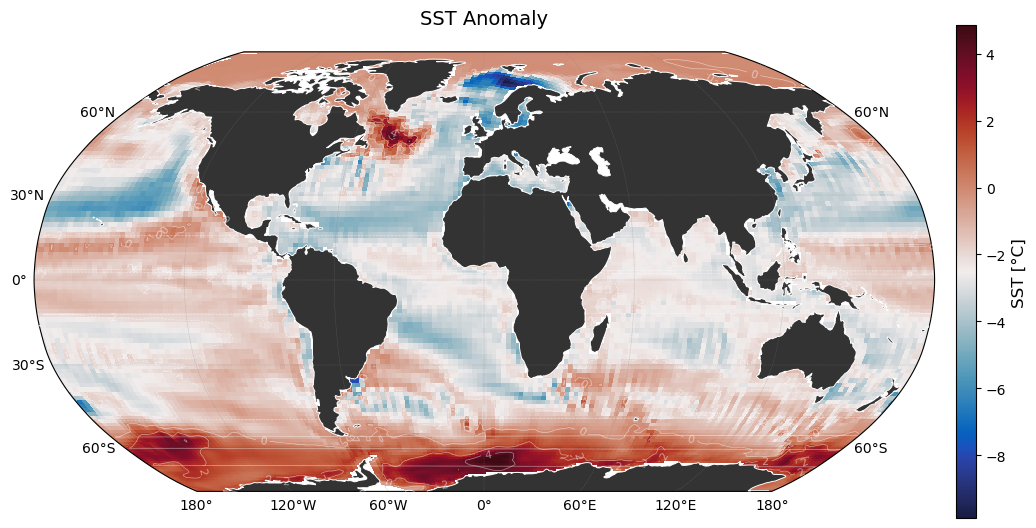

In [13]:
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())

# 1. Plot del campo di temperatura (shading)
# Usiamo pcolormesh per il fondo continuo
im = ax.pcolormesh(
    ds0.lon, ds0.lat, diff0,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.balance, 
    shading='auto'
)

# 2. Aggiunta dei Contour (linee di livello)
# Definiamo i livelli, ad esempio ogni 2 gradi
levels = range(-2, 32, 2)
contours = ax.contour(
    ds0.lon, ds0.lat, diff0,
    levels=levels,
    colors='white',
    linewidths=0.5,
    alpha=0.5,
    transform=ccrs.PlateCarree()
)
# Etichette sulle linee (opzionale)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# 3. Estetica professionale
ax.add_feature(cfeature.LAND, facecolor='#333333', zorder=2) # Terra scura per contrasto
ax.coastlines(resolution='110m', color='white', linewidth=0.7, zorder=3)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cb = plt.colorbar(im, orientation='vertical', pad=0.02, aspect=25, shrink=0.8)
cb.set_label('SST [°C]', fontsize=12)

plt.title('SST Anomaly', fontsize=14, pad=20)
plt.show()

In [4]:
# 1. Caricamento del domain_cfg per la maschera
ds_dom = xr.open_dataset('/ec/res4/hpcperm/itas/data/ece-4-database/nemo/domain/ORCA2/domain_cfg.nc')
# In ORCA2, top_level o tmask == 0 indica la terra. 
# Creiamo una maschera dove la terra è 1 e il mare è NaN
land_mask = ds_dom.top_level.isel(time_counter=0).where(ds_dom.top_level.isel(time_counter=0) == 0)

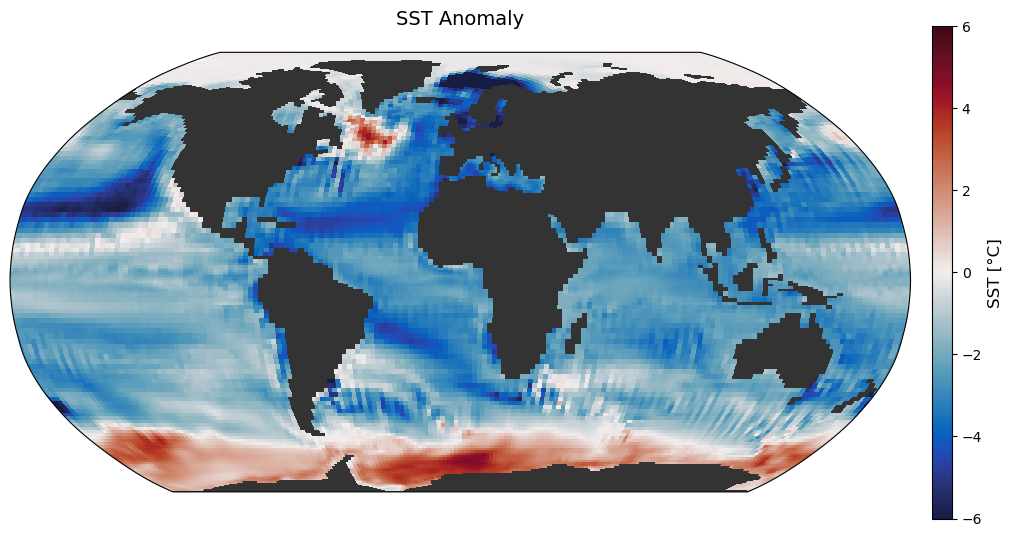

In [ ]:
from matplotlib.colors import ListedColormap
dark_grey_cmap = ListedColormap(['#333333'])

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())

# --- Plot del campo di temperatura ---
im = ax.pcolormesh(
    ds0.lon, ds0.lat, diff0, # Usa le coordinate del dataset ORCA
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.balance, 
    shading='auto', vmin=-6, vmax=6
)

# --- Plot della Maschera dei Continenti (ORCA2) ---
# Sovrapponiamo la terra usando un colore solido
ax.pcolormesh(
    ds_dom.nav_lon, ds_dom.nav_lat, land_mask,
    transform=ccrs.PlateCarree(),
    cmap=dark_grey_cmap, # Colore per la terra (es. grigio scuro)
    vmin=0, vmax=1,
    zorder=2
)

# Colorbar
cb = plt.colorbar(im, orientation='vertical', pad=0.02, aspect=25, shrink=0.8)
cb.set_label('SST [°C]', fontsize=12)

plt.title('SST Anomaly', fontsize=14, pad=20)
plt.show()

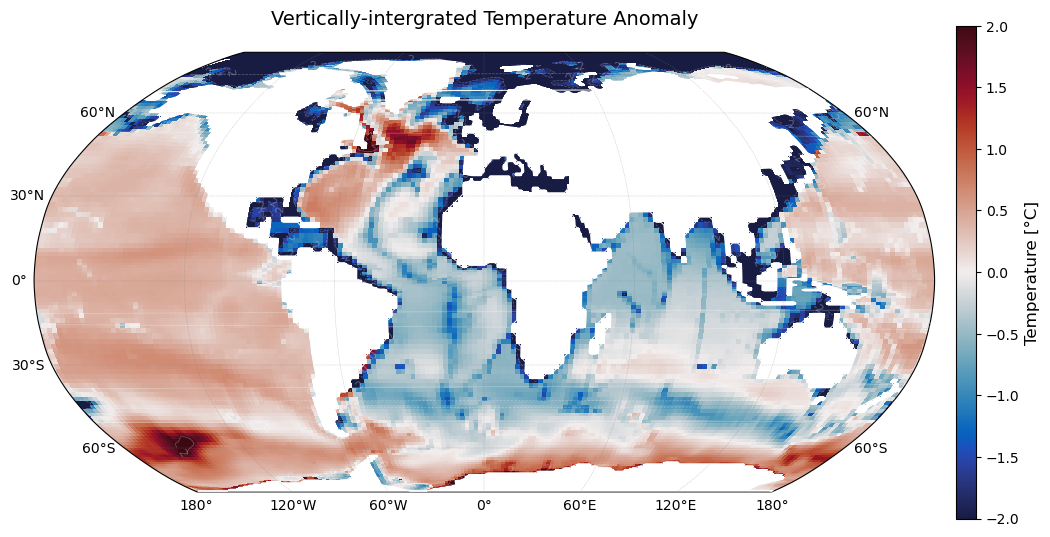

In [17]:
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.Robinson())

# --- Plot del campo di temperatura ---
im = ax.pcolormesh(
    ds0.lon, ds0.lat, diff_int, # Usa le coordinate del dataset ORCA
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.balance, 
    shading='auto', vmin=-2, vmax=2
)

# --- Plot della Maschera dei Continenti (ORCA2) ---
# Sovrapponiamo la terra usando un colore solido
ax.pcolormesh(
    ds_dom.nav_lon, ds_dom.nav_lat, land_mask,
    transform=ccrs.PlateCarree(),
    cmap='Greys', # Colore per la terra (es. grigio scuro)
    vmin=0, vmax=1,
    zorder=2
)

# --- Linea di costa del modello (Contorno della maschera) ---
# Questo sostituisce ax.coastlines() con i bordi reali di ORCA2
ax.contour(
    ds_dom.nav_lon, ds_dom.nav_lat, ds_dom.top_level.isel(time_counter=0),
    levels=[0.5],
    colors='white',
    linewidths=0.7,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# --- Overlay dei Contour di Temperatura ---
levels = range(-2, 32, 2)
contours = ax.contour(
    ds0.lon, ds0.lat, diff_int,
    levels=levels,
    colors='white',
    linewidths=0.5,
    alpha=0.3,
    transform=ccrs.PlateCarree(),
    zorder=4
)

# Etichette sulle linee (opzionale)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# Grilines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Colorbar
cb = plt.colorbar(im, orientation='vertical', pad=0.02, aspect=25, shrink=0.8)
cb.set_label('Temperature [°C]', fontsize=12)

plt.title('Vertically-intergrated Temperature Anomaly', fontsize=14, pad=20)
plt.show()